In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import re #regular expression

import matplotlib.pyplot as plt #For plotting graphs
import matplotlib.ticker as mtick
#plt.style.use('ggplot')
#include plots in the notebook
%matplotlib inline 
import seaborn as sns #For plotting graphs
#sns.set(style='darkgrid')
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder #for creating dummy variables out of categorical variables
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, \
confusion_matrix, mean_squared_error, balanced_accuracy_score,roc_curve
import matplotlib.pyplot as plt

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV,RandomizedSearchCV
from scipy.stats import chi2_contingency

# Classifier Libraries
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Undersampling and Oversampling Libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss, CondensedNearestNeighbour,TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.metrics import classification_report_imbalanced

from sklearn.preprocessing import OrdinalEncoder

from optbinning import OptimalBinning

# Recursive Feature Elimination
import warnings
# warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
warnings.filterwarnings('ignore')
# from probatus.feature_elimination import ShapRFECV

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

#utilities
import collections

import warnings
warnings.filterwarnings("ignore")

# from LGBMBayesianOptimization import bayes_parameter_opt_lgb
from functions import *

import openpyxl

pd.set_option('display.max_colwidth', None)

import shap
# print the JS visualization code to the notebook
shap.initjs()

(CVXPY) Feb 06 08:29:59 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.6.2534). Expected < 9.5.0.Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 06 08:29:59 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.6.2534). Expected < 9.5.0.Please open a feature request on cvxpy to enable support for this version.')


In [2]:
# save the model to disk
import joblib
filename = 'model_lgbm_20231010.pkl'

# filename = 'model_lgbm_20231010.pkl'


# load the model from disk
loaded_model = joblib.load(filename)
# result = loaded_model.score(X_test, Y_test)

In [3]:
run_date_str = '20231010'
s3_output = f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}' # output directory

# df = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}/processed_train.parquet') 

df_train_encoded = pd.read_pickle('/home/ec2-user/SageMaker/toastcap_pre_90_pd/notebooks/Development Notebooks/data/df_train_encoded.pkl')
df_test_encoded = pd.read_pickle('/home/ec2-user/SageMaker/toastcap_pre_90_pd/notebooks/Development Notebooks/data/df_test_encoded.pkl')
df_val_encoded = pd.read_pickle('/home/ec2-user/SageMaker/toastcap_pre_90_pd/notebooks/Development Notebooks/data/df_val_encoded.pkl')

In [4]:
print('Not Default vs Default\n',df_train_encoded.label_90.value_counts(dropna=False))
var = round(df_train_encoded.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%",format(var))
print("Total", df_train_encoded.shape[0])

print('Not Default vs Default\n',df_test_encoded.label_90.value_counts(dropna=False))
var = round(df_test_encoded.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))
print("Total", df_test_encoded.shape[0])

print('Not Default vs Default\n',df_val_encoded.label_90.value_counts(dropna=False))
var = round(df_val_encoded.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))
print("Total", df_val_encoded.shape[0])

Not Default vs Default
 0.0    128300
1.0      7579
Name: label_90, dtype: int64
The event rate is {}% 5.58
Total 135879
Not Default vs Default
 0.0    42767
1.0     2527
Name: label_90, dtype: int64
The event rate is 5.58%
Total 45294
Not Default vs Default
 0.0    54845
1.0     3020
Name: label_90, dtype: int64
The event rate is 5.22%
Total 57865


In [5]:
df_train_encoded = df_train_encoded[df_train_encoded['flag_ge50_3d_over_7d'] == 1]
df_test_encoded = df_test_encoded[df_test_encoded['flag_ge50_3d_over_7d'] == 1]
df_val_encoded = df_val_encoded[df_val_encoded['flag_ge50_3d_over_7d'] == 1]

y_train = df_train_encoded['label_90']
y_test = df_test_encoded['label_90']
y_val = df_val_encoded['label_90']

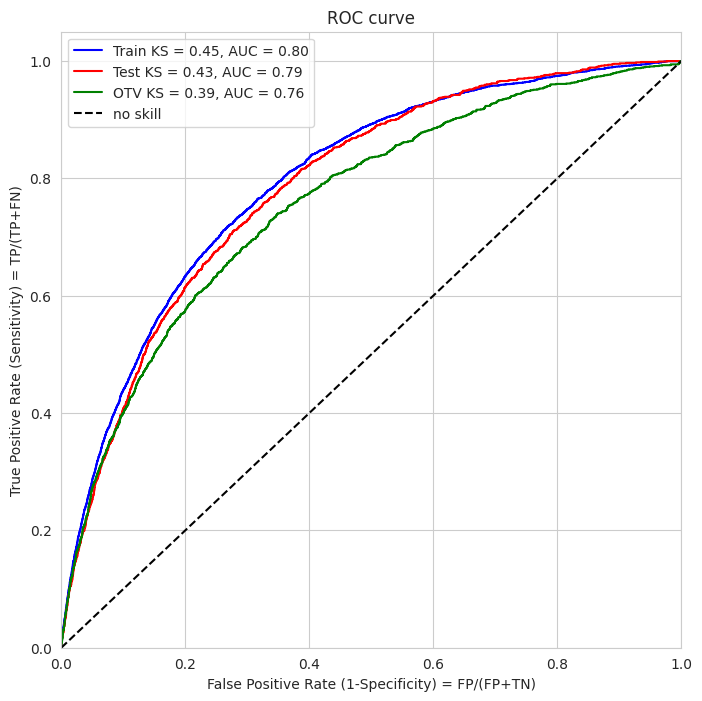

In [6]:
# from functions import plot_auc3
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc2(ax, y_train, df_train['y_pred'], y_test, df_test['y_pred'])
plot_auc3(ax, y_train, df_train_encoded['y_pred'], y_test, df_test_encoded['y_pred'], df_val_encoded.label_90, df_val_encoded['y_pred'])

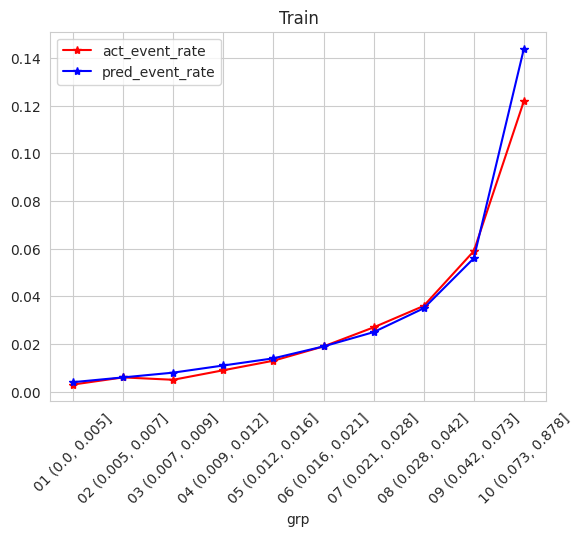

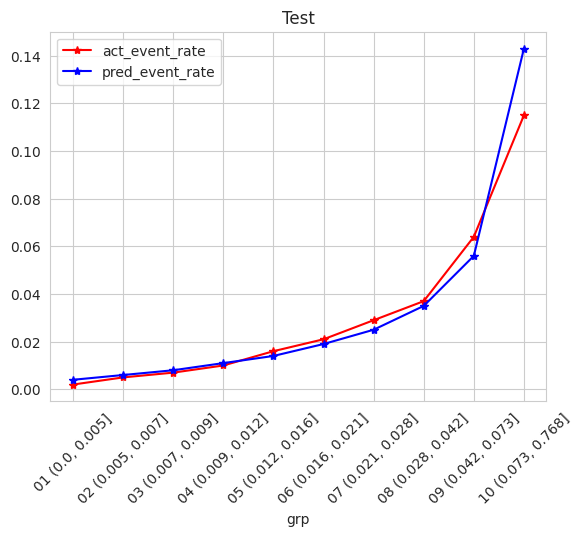

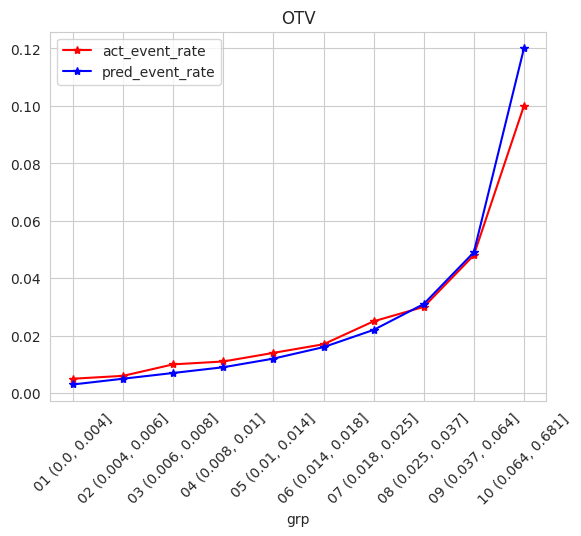

In [7]:
ror_train = exp_vs_act(df_train_encoded,'y_pred','label_90','Train')
ror_test = exp_vs_act(df_test_encoded,'y_pred','label_90','Test')
ror_val = exp_vs_act(df_val_encoded,'y_pred','label_90','OTV')

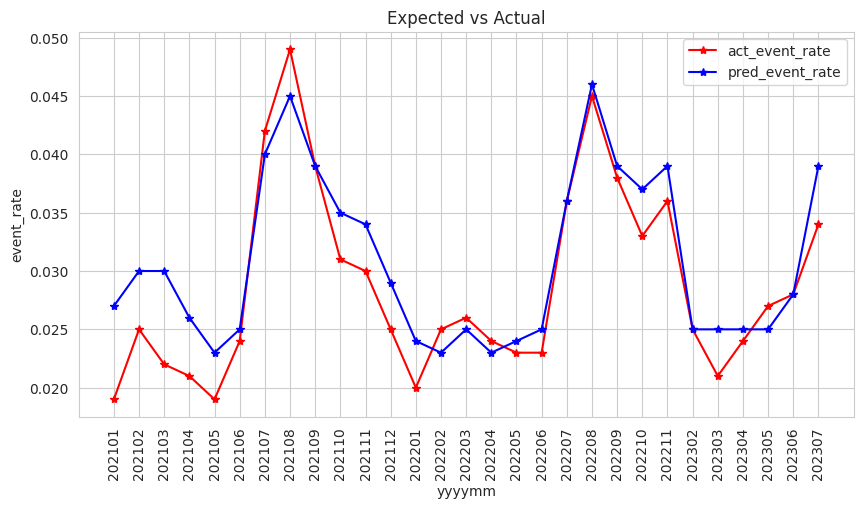

In [8]:
df = pd.concat([df_train_encoded,df_test_encoded,df_val_encoded])
target = 'label_90'
score = 'y_pred'
date = 'yyyymm'
exp_vs_act_date(df,score,date,target)